In [20]:
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats, ndimage

import sys
from pathlib import Path

root = Path().resolve()

sys.path.insert(0, str(root / 'code'))
from sde_routines_condi import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_entropy import*
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root  / 'data'))
from data import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Get the data

In [21]:
#Orthogonal Wavelet
W =   DefineWavelet('Db',m=4,device=device)

In [23]:
Data = generate_gaussian((512,), 1000, alpha=2)
n1 = 256  # desired subseries length
Data = split_periodize_reshape(Data, n1)
for j in range(1):
    Data =W.decompose(Data)[1]#(W.decompose(Data)[1])[1]#Data[:,:,::2]+Data[:,:,1::2]
x1 = normalize(Data[:500]).to(device)
print(x1.shape)

torch.Size([500, 1, 128])


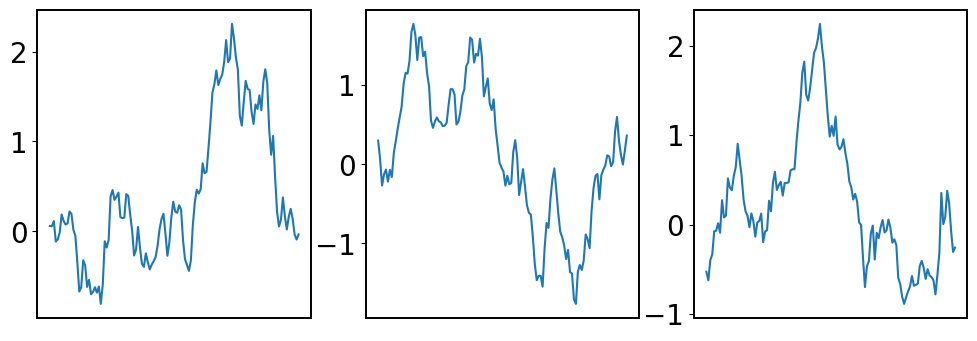

In [24]:
plot_time_series_row(x1, 3)

In [25]:
#load low freq data
config_load = 'LowFreq_64_J_6_Q_1_sigma_1'
x_k_condi = load_results( root, config_load)[0].to(device)[:500]

#renormalize data before conditioning
std =W.decompose(x1)[1].std()
x_k_condi = x_k_condi*std

print(x_k_condi.shape)

torch.Size([500, 1, 64])


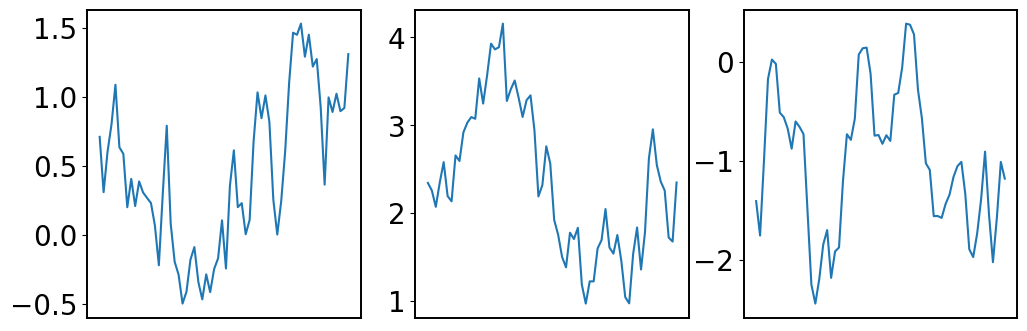

In [26]:
plot_time_series_row(x_k_condi, 3)

### Choose the model

In [33]:
n1, channels, M = x1.shape
print(f'(B, C, T) = ({n1}, {channels}, {M}).')

J = 7
Q = 1

# choose terms in the model
terms = ['Scattering_Second_Order','Scattering_Fourth_Order_Real']
#Filters
filters = return_Filters(M, J, 1, device=device)
filters_Q = return_Filters(M, J, Q, device=device)

(B, C, T) = (500, 1, 128).


In [34]:
potentials = get_1d_potentials_condi(W,terms, J, filters,Q=Q,filters_Q=filters_Q, parallel=False)

## Solve the SDE

In [35]:
# SDE parameters
interpolant = 'Cos'
nt          = 2500
t           = 1-(1-torch.linspace(0, 1, nt + 1))*1
sigma       = 1

nb_workers      = x1.shape[0] # number of particles
nb_interpolants = x1.shape[0] # number of I_t (not necessarily the dataset size, since several noise paths could be considered per data sample)

batch_size = x1.shape[0]

regularization = 1e-4

Solver = SDE_condi(W,x1, nb_workers, nb_interpolants, t, sigma, potentials, batch_size, device=device, regularization=regularization, interpolant=interpolant
                   ,x_k_condi =x_k_condi)

Signal detected as 1D: (B, C, T) = (500, 1, 64).
The model has 27 potentials.


In [36]:
config = 'FullRes_'+str(M)+'_J_'+str(J)+'_Q_'+str(Q)+'_sigma_'+str(sigma)

In [37]:
print(config)

FullRes_128_J_7_Q_1_sigma_1


In [ ]:
xt, barphi_e, barphi_p, eta_t, theta_t, dH_t_bound = Solver()

2083it [01:43, 20.10it/s]

In [ ]:
save_results(xt, theta_t, dH_t_bound, t, root, config)

In [ ]:
# Check (non negligible) moments matching

threshold = 1e-8 # threshold above which should be considered

plot_moment_matching(barphi_e, barphi_p, t, threshold)

In [ ]:
xt, theta_t, dH_t_bound, t =load_results( root, config)

## Analyze the result

Looking at the samples and moment matching along the dynamics:

In [ ]:
# Visual Check
Compare_time_series_row(x1,xt, 5)
# Visual High_freq
Compare_time_series_row(W.decompose(x1)[0],W.decompose(xt)[0], 5)

In [ ]:
visual_comparison(x1, xt, c4_fixed_tau=10,a_ylim=(1e-3, 1),n_bins=50, smooth=True, smooth_sigma=1.5,
                      pdf_xlim=(-6, 6), epsilon=1e-8)